### Analysis of results

In [1]:
def default_params(): 
    return {
        'aligments_base' : '/workspaces/CodeSmells/data/extension/mitigation/alignments/base/M1_q_none/aligned_smells.json',
        'aligments_prompted' : '/workspaces/CodeSmells/data/extension/mitigation/alignments/prompted/M2_q_none/aligned_smells.json',
        'score': 'code_smell_actual_prob_median',
    }
params = default_params()


### Imports

In [2]:
import pandas as pd

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

### Dataset Loading

In [4]:
aligments_base_df = pd.read_json(params['aligments_base'])
aligments_prompted_df = pd.read_json(params['aligments_prompted'])

In [5]:
aligments_prompted_df.columns

Index(['id', 'commit_id', 'repo', 'path', 'file_name', 'fun_name',
       'commit_message', 'code', 'url', 'language', 'ast_errors',
       'n_ast_errors', 'ast_levels', 'n_whitespaces', 'n_words', 'vocab_size',
       'complexity', 'nloc', 'token_counts', 'n_ast_nodes', 'n_identifiers',
       's_msg_id', 's_line', 's_column', 's_end_line', 's_end_column',
       's_code', 'category', 'input_lenght', 'prompt_id', 'prompt',
       'original_code', 'input_ids', 'prompt_ids', 'max_prob', 'min_prob',
       'actual_prob', 'loss', 'code_smell_pos', 'code_smell_actual_logits',
       'code_smell_max_logits', 'code_smell_min_logits',
       'code_smell_actual_prob_median', 'code_smell_max_prob_median',
       'code_smell_min_prob_median', 'code_smell_actual_prob_mean',
       'code_smell_max_prob_mean', 'code_smell_min_prob_mean',
       'code_smell_psc_entropy', 'code_smell_psc_relative'],
      dtype='object')

### Extract Distributions

In [6]:
def extract_distributions(df, score, type):
    distribution_df = df[[params['score']]].copy()
    distribution_df = distribution_df.rename(columns={score: 'value'})
    distribution_df['type'] = type
    return distribution_df

In [7]:
base_distribuion_df = extract_distributions(aligments_base_df, params['score'], 'base')
prompted_distribuion_df = extract_distributions(aligments_prompted_df, params['score'], 'prompted')
## merge distributions
distribution_df = pd.concat([base_distribuion_df, prompted_distribuion_df], ignore_index=True)

In [8]:
# Remove outliers from distribution_df using IQR
Q1 = distribution_df['value'].quantile(0.25)
Q3 = distribution_df['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
distribution_df = distribution_df[(distribution_df['value'] >= lower_bound) & (distribution_df['value'] <= upper_bound)]

### Visualization

/tmp/ipykernel_993097/2433372837.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_993097/2433372837.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", frameon=False)


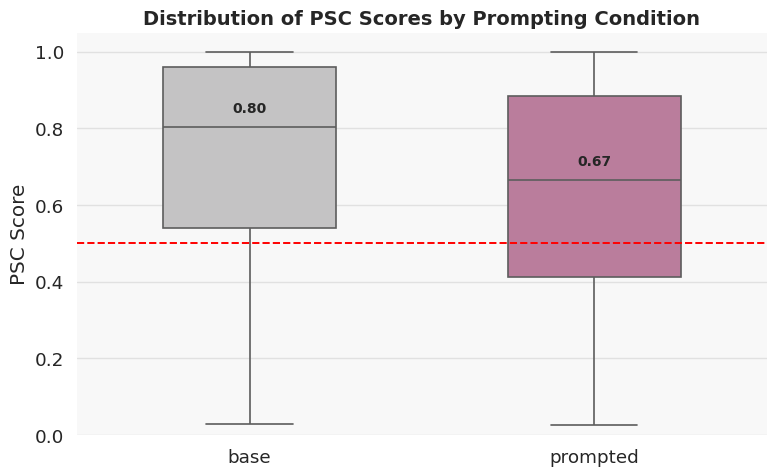

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plot style and background
sns.set(style="whitegrid", font_scale=1.2, rc={
    "axes.facecolor": "#f8f8f8",
    "axes.edgecolor": "white",
    "grid.color": "#e1e1e1",
    "axes.grid": True,
})

# Custom color palette
custom_palette = {"base": "#c4c3c4", "prompted": "#c4739c"}

# Create boxplot
plt.figure(figsize=(4, 5))
ax = sns.boxplot(
    x="type",
    y="value",
    data=distribution_df,
    palette=custom_palette,
    width=0.5,
    fliersize=3,
    linewidth=1.2
)

# Add median labels above each box
medians = distribution_df.groupby("type")["value"].median()
for i, (label, median_val) in enumerate(medians.items()):
    ax.text(i, median_val + 0.03, f"{median_val:.2f}",
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Add horizontal line for threshold
plt.axhline(y=0.5, color="red", linestyle="--", linewidth=1.4)

# Axis labels and title
plt.title("Distribution of PSC Scores by Prompting Condition", fontsize=14, weight='semibold')
plt.xlabel("")
plt.ylabel("PSC Score")

# Remove spines and improve layout
for spine in ax.spines.values():
    spine.set_visible(False)

plt.legend(loc="upper right", frameon=False)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()
